# NYS Donate Life

# Reseach Question

How can New York State identify and prioritize communities at risk of low organ donor registration to support equity-centered outreach and resource allocation?

#### Dataset
1. https://health.data.ny.gov/Health/New-York-State-Donate-Life-Registry-Enrollment-by-/gvq6-s8vf/about_data
2. https://www.nyc.gov/assets/planning/download/office/data-maps/nyc-population/census2000/sf1p11.xls
- ? https://www.census.gov/programs-surveys/geography/guidance/geo-areas/zctas.html
- ? https://www.census.gov/programs-surveys/acs/data.html
- ? https://www2.census.gov/geo/docs/maps-data/data/rel2020/cd-sld/tab20_cd11820_zcta520_st36.txt


In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle

In [192]:
donate_df = pd.read_csv('New_York_State_Donate_Life_Registry_Enrollment_by_Zip_Code_20260304.csv', low_memory=False)
donate_df.head()

,Zip Code,Year,Month,Registry Enrollments
0,14850,2008,9,246
1,11215,2008,9,199
2,10025,2008,9,193
3,11238,2008,9,160
4,11201,2008,9,154


### data cleaning

In [193]:
# replace all commas in `Registry Enrollments` col with nothing
donate_df['Registry Enrollments'] = donate_df['Registry Enrollments'].str.replace(',', '')

In [194]:
# convert `Registry Enrollments` col into a int64
#df_2025["zip"] = df_2025["zip"].astype("Int64")
donate_df['Zip Code'] = donate_df['Zip Code'].astype('int64')
donate_df['Registry Enrollments'] = donate_df['Registry Enrollments'].astype('int64')

In [197]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,160431.000000,160431.000000,160431.000000,160431.000000
mean,12331.312465,2016.748683,6.540694,42.606853
std,1442.191947,5.022199,3.429029,40.523274
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,9.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


# 1️⃣ `donate_df`
- num rows = 159,711 (one row per month, per year, per zip code)
- column = 4
    - `Zip Code` range: 7310 – 14905 (typo @ min?)
        - unique = 1,331
    - `Year` range: 2008 - 2026 (19 years)
    - `Month`range: 1-12
    - `Registry Enrollments` range: 10 – 1,104

to do:
- aggregate all months of year by zipcode to see trends over years 2008-2026
- see which zip codes de/increased enrollment over time

@ first glance: 
- (1) zip codes with high enrolment per month & year are in Manhattan 10021 UES, 10025 UWS/Morningside Heights, 10024 UWS, 10023 UWS;
- (2) only 1 in Brooklyn 11215. 
- What would aggregate data show?

@ missing data:
- None!!!

@ duplicates:
- 22 rows are duplicates (2021, 2022, 2024)
- totaling ~800 registry enrollments 
- decide what to do with duplicates

In [198]:
donate_df.describe()

,Zip Code,Year,Month,Registry Enrollments
count,160431.000000,160431.000000,160431.000000,160431.000000
mean,12331.312465,2016.748683,6.540694,42.606853
std,1442.191947,5.022199,3.429029,40.523274
min,7310.000000,2008.000000,1.000000,10.000000
25%,11218.000000,2012.000000,4.000000,17.000000
50%,12053.000000,2017.000000,7.000000,29.000000
75%,13619.000000,2021.000000,9.000000,53.000000
max,14905.000000,2026.000000,12.000000,1104.000000


In [199]:
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160431 entries, 0 to 160430
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Zip Code              160431 non-null  int64
 1   Year                  160431 non-null  int64
 2   Month                 160431 non-null  int64
 3   Registry Enrollments  160431 non-null  int64
dtypes: int64(4)
memory usage: 4.9 MB


In [131]:
donate_df.nunique()

Zip Code                1331
Year                      19
Month                     12
Registry Enrollments     423
dtype: int64

In [132]:
donate_df.columns

Index(['Zip Code', 'Year', 'Month', 'Registry Enrollments'], dtype='object')

In [133]:
# rename columns
donate_df.rename(columns={
    'Zip Code': 'zip',
    'Year': 'year',
    'Month': 'month', 
    'Registry Enrollments': 'donors'}, inplace=True) 

In [134]:
# check for missing data
missing_values = donate_df.isna().sum()
missing_values

zip       0
year      0
month     0
donors    0
dtype: int64

In [135]:
# check for duplicates
key_cols = ['zip', 'year', 'donors']
duplicates = donate_df[donate_df.duplicated(key_cols, keep=False)].sort_values(key_cols)
print(duplicates)
print('\n')
print('Duplicates Sum:', duplicates['donors'].sum())
print('\n')
print(duplicates.count()) 

          zip  year  month  donors
2943    10001  2009      2    34.0
11625   10001  2009     12    34.0
7351    10001  2009      7    49.0
9143    10001  2009      9    49.0
8181    10001  2009      8    64.0
...       ...   ...    ...     ...
148094  14905  2024      9    35.0
154259  14905  2025      5    17.0
157458  14905  2025      9    17.0
153395  14905  2025      4    20.0
158827  14905  2025     11    20.0

[48653 rows x 4 columns]


Duplicates Sum: 1427441.0


zip       48653
year      48653
month     48653
donors    48653
dtype: int64


# 2️⃣ `yearly_df`
- aggregate by month & year
- num rows = 18,230 (one row per zip code, per year)
- cols = 3
    - `Zip Code` range: 7310 – 14905 (typo @ min?) --> min = 10001
        - unique 1,331
    - `Year` range: 2008 - 2026 (19 years)
    - `Registry Enrollments` range: 10 – 4,063

In [138]:
# aggregate data by month & year
yearly_df = (
    donate_df
    .groupby(['zip', 'year'], as_index=False)
    .agg({'donors': 'sum'}))

In [139]:
yearly_df.head().sort_values('zip', ascending=True )

,zip,year,donors
0,7310,2016,10.0
1,10001,2008,167.0
2,10001,2009,709.0
3,10001,2010,759.0
4,10001,2011,788.0


In [140]:
yearly_df.describe()

,zip,year,donors
count,18906.000000,18906.000000,18906.000000
mean,12482.192214,2016.859621,361.549774
std,1420.322256,5.354779,433.238861
min,7310.000000,2008.000000,10.000000
25%,11366.000000,2012.000000,59.000000
50%,12414.000000,2017.000000,218.000000
75%,13734.000000,2021.000000,494.000000
max,14905.000000,2026.000000,4058.000000


In [141]:
yearly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18906 entries, 0 to 18905
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   zip     18906 non-null  int64  
 1   year    18906 non-null  int64  
 2   donors  18906 non-null  float32
dtypes: float32(1), int64(2)
memory usage: 369.4 KB


In [142]:
yearly_df.nunique()

zip       1331
year        19
donors    1831
dtype: int64

# 3️⃣ `yearly_totals`
- see data in table format
- num rows = 18 (one row per year)
- cols = 2
    - `Year` range: 2008 – 2026 (19 years)
    - `Registry Enrollments` range: 26 - 576,909

@ first glance:
- start of data collection (2008) lowest num enrollment (62797), lack of interest, lack of data collection?
- YTD (Feb 2026) low enrollment (22038)

In [143]:
# see data in table format
yearly_totals = (
    yearly_df
    .groupby('year', as_index=False)
    .agg({'donors': 'sum'})
    .sort_values('year')
)
yearly_totals

,year,donors
0,2008,62793.0
1,2009,453730.0
2,2010,449352.0
3,2011,486094.0
4,2012,498936.0
5,2013,280201.0
6,2014,230753.0
7,2015,324316.0
8,2016,403118.0
9,2017,576823.0


In [144]:
yearly_totals.describe()

,year,donors
count,19.000000,19.000000
mean,2017.000000,359761.062500
std,5.627314,153167.578125
min,2008.000000,22038.000000
25%,2012.500000,298566.000000
50%,2017.000000,342203.000000
75%,2021.500000,469912.000000
max,2026.000000,576823.000000


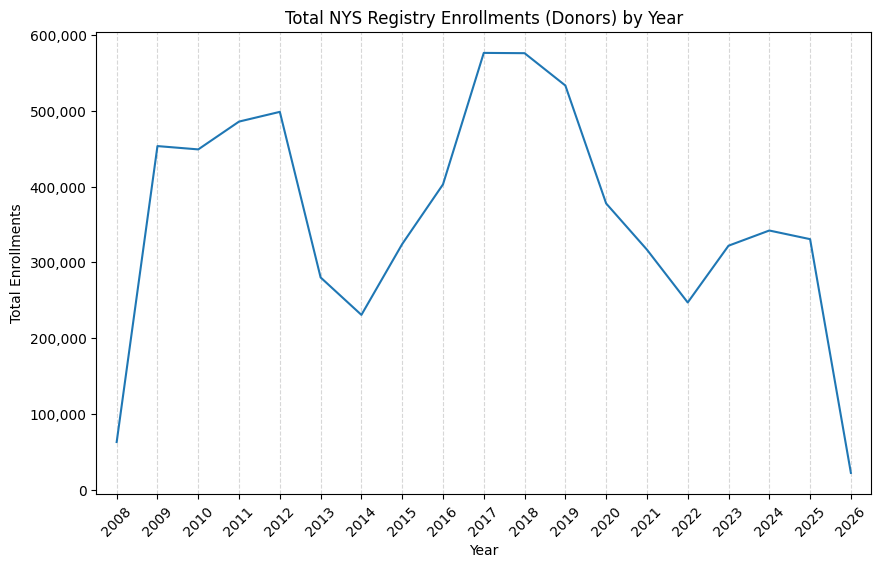

In [148]:
# visualize `yearly_totals_df`

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_totals,
    x="year",
    y="donors"
)

plt.xlim(2007.5, 2026.5)
plt.xticks(np.arange(2008, 2027, 1))
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.title("Total NYS Registry Enrollments (Donors) by Year")
plt.xlabel("Year")
plt.ylabel("Total Enrollments")
plt.show()

In [149]:
## pickle donate_df yearly_df yearly_totals
donate_df.to_pickle("donate_df.pkl")
yearly_df.to_pickle("yearly_df.pkl")
yearly_totals.to_pickle("yearly_totals.pkl")

In [150]:
## pickle donate_df yearly_df yearly_totals

with open("donate_df.pkl", "rb") as f:
    donate_df = pickle.load(f)

with open("yearly_df.pkl", "rb") as f:
    yearly_df = pickle.load(f)

with open("yearly_totals.pkl", "rb") as f:
    yearly_totals = pickle.load(f)

## Visualize 2025 for each zip code? 
No, too many rows (1,011)

In [152]:
# look at 2025
df_2025 = yearly_df[yearly_df['year'] == 2025].copy()
df_2025

,zip,year,donors
18,10001,2025,902.0
37,10002,2025,1377.0
56,10003,2025,1561.0
75,10004,2025,93.0
94,10005,2025,303.0
...,...,...,...
18828,14895,2025,217.0
18847,14901,2025,327.0
18866,14903,2025,169.0
18885,14904,2025,401.0


# 4️⃣ Zip Code Data

## zipcode_race_df 
https://www.nyc.gov/assets/planning/download/office/data-maps/nyc-population/census2000/sf1p11.xls 

In [163]:
zipcode_race_df = pd.read_excel('nyc_zip_codes.xls', header=6)
zipcode_race_df

,Borough,ZIPCODES,Unnamed: 2,White,Black/ African American,American Indian and Alaska Native,Asian,Native Hawaiian and Other Pacific Islander,Some Other Race,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Manhattan,10001.0,17310.0,9166.0,1439.0,38.0,2641.0,5.0,72.0,464.0,3485.0,9806.0
2,Manhattan,10002.0,84870.0,13371.0,5184.0,111.0,41658.0,20.0,272.0,1550.0,22704.0,32965.0
3,Manhattan,10003.0,53673.0,39367.0,2209.0,61.0,6447.0,56.0,238.0,1234.0,4061.0,31154.0
4,Manhattan,10004.0,1225.0,861.0,69.0,0.0,150.0,4.0,14.0,48.0,79.0,779.0
...,...,...,...,...,...,...,...,...,...,...,...,...
200,Queens,11691.0,56184.0,12312.0,27681.0,168.0,884.0,13.0,526.0,1717.0,12883.0,19424.0
201,Queens,11692.0,15893.0,1625.0,10765.0,60.0,138.0,2.0,139.0,544.0,2620.0,5656.0
202,Queens,11693.0,11157.0,5883.0,3117.0,21.0,218.0,0.0,49.0,247.0,1622.0,4607.0
203,Queens,11694.0,19278.0,15855.0,1109.0,18.0,438.0,6.0,19.0,169.0,1664.0,9038.0


In [165]:
zipcode_race_df.columns

Index(['Borough', 'ZIPCODES', 'Unnamed: 2', 'White',
       '   Black/ African American', '     American Indian and Alaska Native',
       '      Asian', 'Native Hawaiian and Other Pacific Islander',
       '  Some Other Race', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [170]:
# rename columns
zipcode_race_df.rename(columns={
    'Borough': 'boro',
    'ZIPCODES': 'zip', 
    'Unnamed: 2': 'pop_total' ,
    'White': 'white',
    '   Black/ African American': 'black',
    '     American Indian and Alaska Native': 'native',
    '      Asian' : 'asian',
    'Native Hawaiian and Other Pacific Islander':'pacific_islander',
    '  Some Other Race': 'other_race',
    'Unnamed: 9': 'non_hispanic',
    'Unnamed: 10': 'hispanic',
    'Unnamed: 11': 'total_housing_units'}, 
                       inplace=True)

In [235]:
zipcode_race_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   boro                 204 non-null    object 
 1   zip                  204 non-null    float64
 2   pop_total            204 non-null    float64
 3   white                204 non-null    float64
 4   black                204 non-null    float64
 5   native               204 non-null    float64
 6   asian                204 non-null    float64
 7   pacific_islander     204 non-null    float64
 8   other_race           204 non-null    float64
 9   non_hispanic         204 non-null    float64
 10  hispanic             204 non-null    float64
 11  total_housing_units  204 non-null    float64
dtypes: float64(11), object(1)
memory usage: 19.3+ KB


In [239]:
zipcode_race_df.isna().sum()

boro                   1
zip                    1
pop_total              1
white                  1
black                  1
native                 1
asian                  1
pacific_islander       1
other_race             1
non_hispanic           1
hispanic               1
total_housing_units    1
dtype: int64

In [243]:
# drop row with NA values
zipcode_race_df = zipcode_race_df.dropna()

In [244]:
# change dtypes for zip and housing units
zipcode_race_df['zip'] = zipcode_race_df['zip'].astype('int64')
zipcode_race_df['total_housing_units'] = zipcode_race_df['total_housing_units'].astype('int64')

In [246]:
zipcode_race_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204 entries, 1 to 204
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   boro                 204 non-null    object 
 1   zip                  204 non-null    int64  
 2   pop_total            204 non-null    float64
 3   white                204 non-null    float64
 4   black                204 non-null    float64
 5   native               204 non-null    float64
 6   asian                204 non-null    float64
 7   pacific_islander     204 non-null    float64
 8   other_race           204 non-null    float64
 9   non_hispanic         204 non-null    float64
 10  hispanic             204 non-null    float64
 11  total_housing_units  204 non-null    int64  
dtypes: float64(9), int64(2), object(1)
memory usage: 20.7+ KB


## `zipcode_df`

In [247]:
zipcode_df = zipcode_race_df[['boro', 'zip', 'total_housing_units']]

In [253]:
zipcode_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 204 entries, 1 to 204
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   boro                 204 non-null    object
 1   zip                  204 non-null    int64 
 2   total_housing_units  204 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 6.4+ KB


In [255]:
zipcode_df.head(5)

,boro,zip,total_housing_units
1,Manhattan,10001,9806
2,Manhattan,10002,32965
3,Manhattan,10003,31154
4,Manhattan,10004,779
5,Manhattan,10005,562


In [256]:
# # pickle zipcode_race_df zipcode_df
# zipcode_race_df.to_pickle("zipcode_race_df.pkl")
# zipcode_df.to_pickle("zipcode_df.pkl")

In [257]:
# # unpickle zipcode_race_df zipcode_df

# with open("zipcode_race_df.pkl", "rb") as f:
#     zipcode_race_df = pickle.load(f)

# with open("zipcode_df.pkl", "rb") as f:
#     zipcode_df = pickle.load(f)

### merge `zipcode_df` with `yearly_df`

In [260]:
# merge 

yearly_df = yearly_df.merge(
    zipcode_df[["zip", "boro"]],
    on="zip",
    how="left"
)

In [262]:
yearly_df

,zip,year,donors,boro
0,7310,2016,10.0,NaN
1,10001,2008,167.0,Manhattan
2,10001,2009,709.0,Manhattan
3,10001,2010,759.0,Manhattan
4,10001,2011,788.0,Manhattan
...,...,...,...,...
18939,14905,2022,178.0,NaN
18940,14905,2023,243.0,NaN
18941,14905,2024,281.0,NaN
18942,14905,2025,262.0,NaN


 # 🔖 if boro is NaN, likely zip not in NYC. 